In [1]:
import torch
from test_dataset import RDataset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np 
from model import TeacherModel, StudentModel1, StudentModel2
import pickle
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
with open('reacher_episodes_full.pkl', 'rb') as f:
    frames = pickle.load(f)


In [4]:
observT, actionsT, targetsT= [], [], []
observS, actionsS, targetsS= [], [], []
count = 0
for i in frames:
    if count < 500:
        observT.append(i['observations'])
        actionsT.append(i['actions'])
        targetsT.append(i['targets'])

        observS.append(i['observations'])
        actionsS.append(i['actions'])
        targetsS.append(i['targets'])
    else:
        observT.append(i['observations'])
        actionsT.append(i['actions'])
        targetsT.append(i['targets'])

    count += 1
print("Shape observ: ", observT[0].shape)
print("Shape actions: ", actionsT[0].shape)
print("Shape targets: ", targetsT[0].shape)

print("Shape observ: ", observS[0].shape)
print("Shape actions: ", actionsS[0].shape)
print("Shape targets: ", targetsS[0].shape)

Shape observ:  (66, 84, 84, 3)
Shape actions:  (66, 2)
Shape targets:  (66, 2)
Shape observ:  (66, 84, 84, 3)
Shape actions:  (66, 2)
Shape targets:  (66, 2)


In [5]:
observT = np.concatenate(observT, axis=0)
actionsT = np.concatenate(actionsT, axis=0)
targetsT = np.concatenate(targetsT, axis=0)

observS = np.concatenate(observS, axis=0)
actionsS = np.concatenate(actionsS, axis=0)
targetsS = np.concatenate(targetsS, axis=0)

print("Shape observ: ", observT[0].shape)
print("Shape actions: ", actionsT[0].shape)
print("Shape targets: ", targetsT[0].shape)

print("Shape observ: ", observS[0].shape)
print("Shape actions: ", actionsS[0].shape)
print("Shape targets: ", targetsS[0].shape)

Shape observ:  (84, 84, 3)
Shape actions:  (2,)
Shape targets:  (2,)
Shape observ:  (84, 84, 3)
Shape actions:  (2,)
Shape targets:  (2,)


In [6]:
def dataset_loader(observ, actions, targets):
    transform = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
    
    # train/val (80/20)
    N = len(observ)
    indices = np.random.permutation(N)
    split = int(0.8 * N)
    train_idx, val_idx = indices[:split], indices[split:]
    
    train_dataset = RDataset(observ[train_idx], actions[train_idx], targets[train_idx], transform)
    val_dataset   = RDataset(observ[val_idx],   actions[val_idx], targets[val_idx], transform)
    
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    return train_loader, val_loader, train_dataset, val_dataset

In [21]:
def train_model(model, observ, actions, targets, model_name, modality=True):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    train_loader, val_loader, train_dataset, val_dataset = dataset_loader(observ, actions, targets)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    train_score, val_score = [], []
    
    num_epochs = 10
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for imgs, acts, target in train_loader:
    
            imgs, acts, target = imgs.to(device), acts.to(device), target.to(device)
            optimizer.zero_grad()
            if modality:
                outputs = model(imgs, target)
            else:
                outputs = model(imgs)
            loss = criterion(outputs, acts)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
        train_loss /= len(train_dataset)
        train_score.append(train_loss)
    
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, acts, target in val_loader:
                imgs, acts, target = imgs.to(device), acts.to(device), target.to(device)
                if modality:
                    outputs = model(imgs, target)
                else:
                    outputs = model(imgs)
                loss = criterion(outputs, acts)
                val_loss += loss.item() * imgs.size(0)
        val_loss /= len(val_dataset)
        val_score.append(val_loss)
    
        print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
    
   
    torch.save(model.state_dict(), model_name)
    return train_score, val_score

In [22]:
model_teacher = TeacherModel()
model_student1 = StudentModel1()
model_student2 = StudentModel2()

In [23]:
scoreTT, scoreVT = train_model(model_teacher, observT, actionsT, targetsT, 'teacher.pth') # Для графиков лоссов
scoreTS1, scoreVS1 = train_model(model_student1, observS, actionsS, targetsS, 'student1.pth')
scoreTS2, scoreVS2 = train_model(model_student2, observS, actionsS, targetsS, 'student2.pth', modality=False)

Epoch 1/10 | Train Loss: 0.8972 | Val Loss: 0.1224
Epoch 2/10 | Train Loss: 0.1390 | Val Loss: 0.0982
Epoch 3/10 | Train Loss: 0.0834 | Val Loss: 0.0454
Epoch 4/10 | Train Loss: 0.0557 | Val Loss: 0.0466
Epoch 5/10 | Train Loss: 0.0429 | Val Loss: 0.0521
Epoch 6/10 | Train Loss: 0.0350 | Val Loss: 0.0429
Epoch 7/10 | Train Loss: 0.0303 | Val Loss: 0.0327
Epoch 8/10 | Train Loss: 0.0325 | Val Loss: 0.0255
Epoch 9/10 | Train Loss: 0.0239 | Val Loss: 0.0309
Epoch 10/10 | Train Loss: 0.0213 | Val Loss: 0.0219
Epoch 1/10 | Train Loss: 27.8322 | Val Loss: 13.3299
Epoch 2/10 | Train Loss: 7.6984 | Val Loss: 4.4925
Epoch 3/10 | Train Loss: 3.4809 | Val Loss: 2.8087
Epoch 4/10 | Train Loss: 2.3385 | Val Loss: 1.9689
Epoch 5/10 | Train Loss: 1.6810 | Val Loss: 1.4747
Epoch 6/10 | Train Loss: 1.2987 | Val Loss: 1.1785
Epoch 7/10 | Train Loss: 1.0369 | Val Loss: 0.9649
Epoch 8/10 | Train Loss: 0.8683 | Val Loss: 0.8686
Epoch 9/10 | Train Loss: 0.7424 | Val Loss: 0.7415
Epoch 10/10 | Train Loss: 0.

In [10]:
state_dict = torch.load('teacher.pth', map_location=device)
model_teacher.load_state_dict(state_dict)
model_teacher.to(device)

state_dict = torch.load('student1.pth', map_location=device)
model_student1.load_state_dict(state_dict)
model_student1.to(device)

state_dict = torch.load('student2.pth', map_location=device)
model_student2.load_state_dict(state_dict)
model_student2.to(device)

model_teacher.eval()
model_student1.eval()
model_student2.eval()

StudentModel2(
  (vision_layer): Sequential(
    (0): Conv2d(3, 32, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 128, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(128, 32, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (head): Sequential(
    (0): Linear(in_features=4608, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [24]:
with open('reacher_episodes_val.pkl', 'rb') as f: 
    frames_val = pickle.load(f)

In [25]:
observ_val, actions_val, targets_val = [], [], []
for i in frames_val:
    observ_val.append(i['observations'])
    actions_val.append(i['actions'])
    targets_val.append(i['targets'])

observ_val = np.concatenate(observ_val, axis=0)
actions_val = np.concatenate(actions_val, axis=0)
targets_val = np.concatenate(targets_val, axis=0)

_, val_loader, _, _ = dataset_loader(observ_val, actions_val, targets_val)

In [26]:
MAE = []

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
with torch.no_grad():
    mae = 0
    for imgs, acts, target in val_loader:
        imgs, acts, target = imgs.to(device), acts.to(device), target.to(device)
        outputs = model_teacher(imgs, target) 
    
        y_pred = outputs.cpu().numpy()
        y_true = acts.cpu().numpy() 

        mae += mean_absolute_error(y_true, y_pred)
    print(f"MAE: {mae / 300}")
    MAE.append(mae / 300)

MAE: 0.04399029756585757


In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
with torch.no_grad():
    mae = 0
    for imgs, acts, target in val_loader:
        imgs, acts, target = imgs.to(device), acts.to(device), target.to(device)
        outputs = model_student1(imgs, target) 
    
        y_pred = outputs.cpu().numpy()
        y_true = acts.cpu().numpy() 

        # Считаем MAE
        mae += mean_absolute_error(y_true, y_pred)
    print(f"MAE: {mae / 300}")
    MAE.append(mae / 300)

MAE: 0.30682011167208356


In [29]:
with torch.no_grad():
    mae = 0
    for imgs, acts, target in val_loader:
        imgs, acts, target = imgs.to(device), acts.to(device), target.to(device)
        outputs = model_student2(imgs) 
    
        y_pred = outputs.cpu().numpy()
        y_true = acts.cpu().numpy() 

        # Считаем MAE
        mae += mean_absolute_error(y_true, y_pred)
    print(f"MAE: {mae / 300}")
    MAE.append(mae / 300)

MAE: 0.29477164149284363


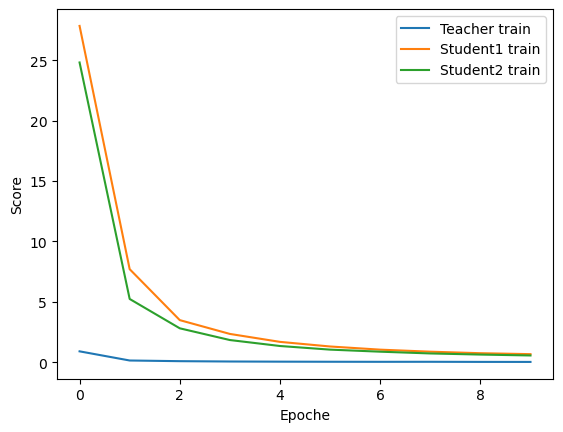

In [31]:
import matplotlib.pyplot as plt

x = [i for i in range(len(scoreTT))]

plt.plot(x, scoreTT, label='Teacher train')
plt.plot(x, scoreTS1, label='Student1 train')
plt.plot(x, scoreTS2, label='Student2 train')
plt.legend()
plt.xlabel('Epoche')
plt.ylabel('Score')
plt.show()

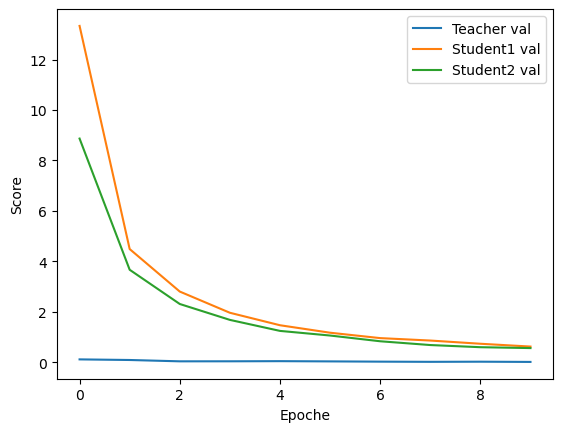

In [32]:
x = [i for i in range(len(scoreTT))]

plt.plot(x, scoreVT, label='Teacher val')
plt.plot(x, scoreVS1, label='Student1 val')
plt.plot(x, scoreVS2, label='Student2 val')
plt.legend()
plt.xlabel('Epoche')
plt.ylabel('Score')
plt.show()

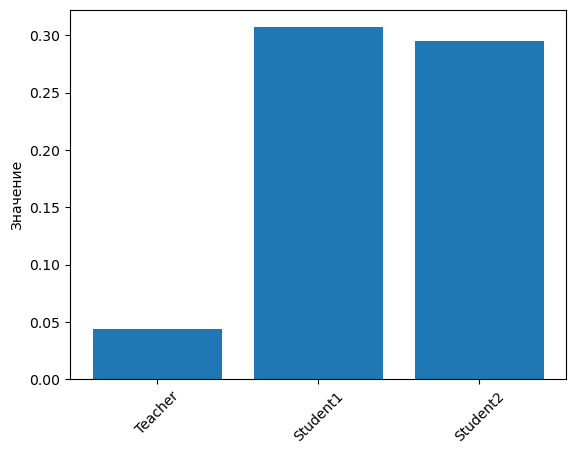

In [33]:
title = ['Teacher', 'Student1', 'Student2']

plt.bar(title, MAE)
plt.xticks(rotation=45)
plt.ylabel('Значение')
plt.show()